# Object Detection using Pre-Trained Models

In [1]:
from pathlib import Path

import numpy as np
import torch

import matplotlib.pyplot as plt
import cv2
from PIL import Image

In [2]:
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights,
    retinanet_resnet50_fpn_v2,
    RetinaNet_ResNet50_FPN_V2_Weights,
    ssd300_vgg16,
    SSD300_VGG16_Weights,
)

In [8]:
def load_image(path: Path):
    return Image.open(path).convert("RGB")

### ClassID to RGB Maps

In [9]:
R = np.array(np.arange(0, 256, 32))
G = np.roll(R, 2)
B = np.roll(R, 4)

COLOUR_IDS = np.array(np.meshgrid(R, G, B)).T.reshape(-1, 3)

### Visualise sample images

In [10]:
ROOT = Path().resolve()
INPUT_DIR = ROOT / "input"
print(INPUT_DIR)

/Users/tapasyagutta/workspace/deep-learning/deep-learning-projects/applications/obj_detection_pre-trained_models/input


In [13]:
images = [load_image(path) for path in INPUT_DIR.glob("*")]

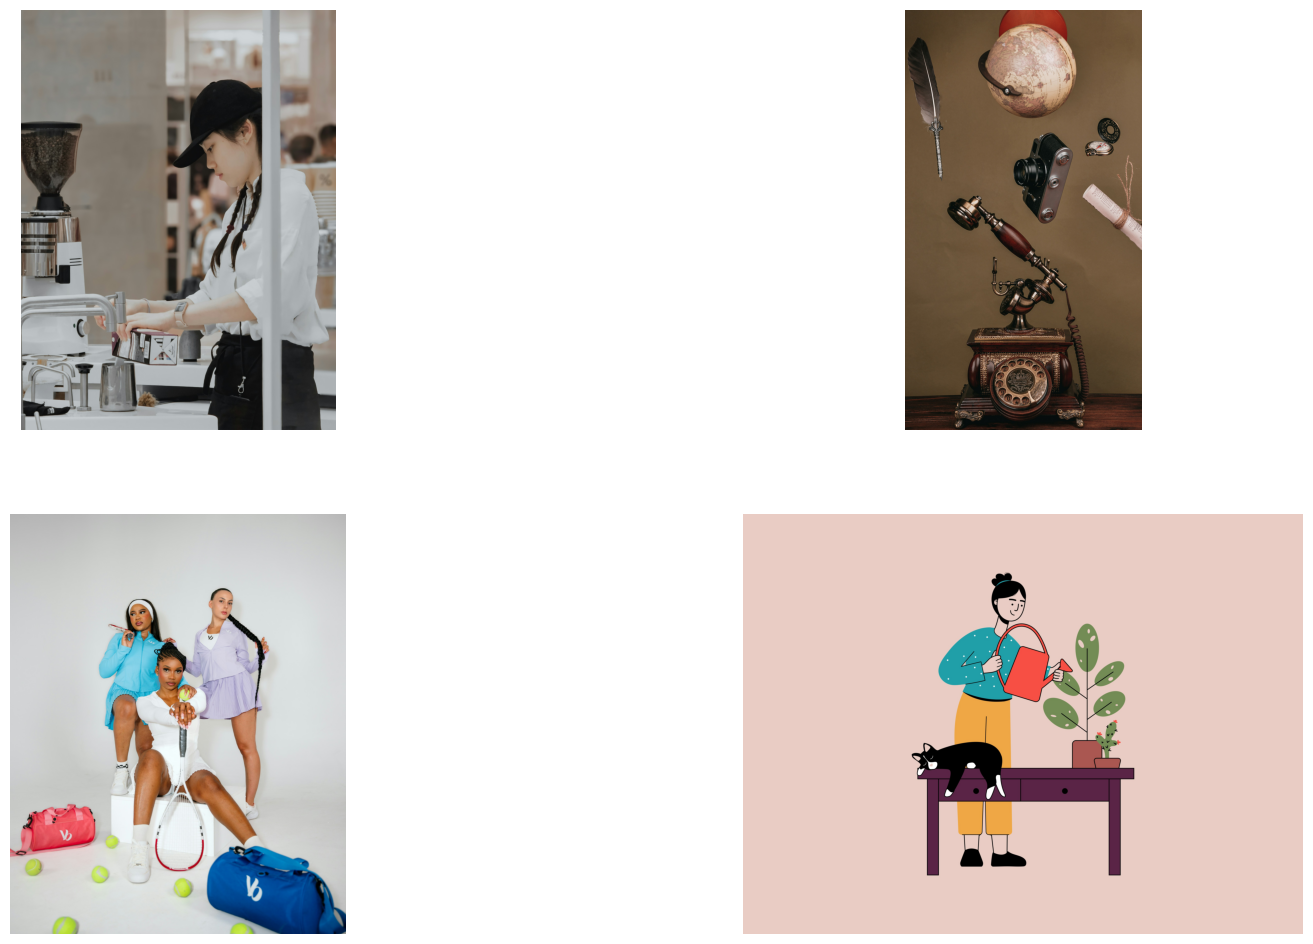

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 12))

idx = 0
for axis in ax.flat:
    axis.imshow(images[idx])
    axis.axis("off")
    idx += 1

## Run Inference

In [16]:
def infer_images(images, model, transforms, device: torch.device):
    model.to(device)
    model.eval()

    results = []
    with torch.no_grad():
        for img in images:
            img_preprocess = transforms(img).to(device)
            predictions = model(img_preprocess.unsqueeze(dim=0))
            result = {
                key: value.detach().cpu().numpy()
                for key, value in predictions[0].items()
            }
            results.append(result)
    return results

In [12]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [27]:
def visualise_image(
    img,
    boxes,
    classes,
    scores,
    cat_id,
    output_path: Path,
    min_score_thresh: float = 0.30,
):
    ids = np.where(scores >= min_score_thresh)

    boxes_thres = boxes[ids]
    classes_thres = classes[ids]
    scores_thres = scores[ids]

    img_bbox = img.copy()
    # im_height, im_width = img.shape[:2]

    for box, cls, score in zip(boxes_thres, classes_thres, scores_thres):

        xmin, ymin, xmax, ymax = box
        class_name = cat_id[cls]
        (left, right, top, bottom) = (int(xmin), int(xmax), int(ymin), int(ymax))

        colour = tuple(COLOUR_IDS[cls % len(COLOUR_IDS)].tolist())[::-1]

        img_bbox = cv2.rectangle(
            img_bbox, (left, top), (right, bottom), colour, thickness=3
        )

        display_txt = "{}: {:.2f}%".format(class_name, 100 * score)

        ((text_width, text_height), _) = cv2.getTextSize(
            display_txt, cv2.FONT_HERSHEY_SIMPLEX, 1.5, 2
        )

        img_bbox = cv2.rectangle(
            img_bbox,
            (left, top - int(1.0 * text_height)),
            (left + int(0.55 * text_width), top),
            colour,
            thickness=-1,
        )

        img_bbox = cv2.putText(
            img_bbox,
            display_txt,
            (left, top - int(0.3 * text_height)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 0),
            2,
        )

    cv2.imwrite(str(output_path), cv2.cvtColor(img_bbox, cv2.COLOR_RGB2BGR))

In [21]:
def visualise_images(
    images, results, cats, output_dir: Path, min_score_thresh: float = 0.5
):
    output_dir.mkdir(exist_ok=True)
    for idx, img_plt in enumerate(images):
        image_np_with_detections = np.array(img_plt)
        visualise_image(
            image_np_with_detections,
            results[idx]["boxes"],
            results[idx]["labels"],
            results[idx]["scores"],
            cats,  # category index
            output_dir / f"{idx}.jpg",
            min_score_thresh=min_score_thresh,
        )

## Faster RCNN with ResNet50_FPN backbone

In [25]:
OUTPUT_DIR_ROOT = ROOT / "output"
OUTPUT_DIR_ROOT.mkdir()

In [22]:
# Inference from Faster RCNN with ResNet50_FPN backbone.

# Initialize the default (best) weights.
# Also an alias for: FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1
weights_fasterrcnn_r50_v2 = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT

# Initialize the inference transforms.
preprocess_fasterrcnn = weights_fasterrcnn_r50_v2.transforms()

# Load the model with pretrained weights.
model_fasterrcnn_r50 = fasterrcnn_resnet50_fpn_v2(weights=weights_fasterrcnn_r50_v2)

# Perform inference.
predictions_fasterrcnn = infer_images(
    images, model_fasterrcnn_r50, preprocess_fasterrcnn, device
)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /Users/tapasyagutta/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100.0%


In [28]:
category_index = weights_fasterrcnn_r50_v2.meta["categories"]
visualise_images(
    images,
    predictions_fasterrcnn,
    category_index,
    OUTPUT_DIR_ROOT / "faster_rcnn",
    min_score_thresh=0.85,
)

## RetinaNet with ResNet50_FPN backbone

In [29]:
# Inference from RetinaNet ResNet-50 FPN v2.

# Initialize the default (best) weights.
# Equivalent to: RetinaNet_ResNet50_FPN_V2_Weights.COCO_V1
weights_retinanet_r50_v2 = RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT

# Define the inference transforms.
preprocess_retinanet = weights_retinanet_r50_v2.transforms()

# Load the model with pretrained weights.
model_retinanet_r50 = retinanet_resnet50_fpn_v2(weights=weights_retinanet_r50_v2)

Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_v2_coco-5905b1c5.pth" to /Users/tapasyagutta/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_v2_coco-5905b1c5.pth


100.0%


In [36]:
# Perform inference.
predictions_retinanet = infer_images(
    images, model_retinanet_r50, preprocess_retinanet, device
)

In [37]:
category_index = weights_retinanet_r50_v2.meta["categories"]
visualise_images(
    images,
    predictions_retinanet,
    category_index,
    OUTPUT_DIR_ROOT / "retinanet",
    min_score_thresh=0.6,
)

## SSD with VGG16

In [31]:
# Inference from SSD VGG 16.

# Initialize the default (best) weights.
# Equivalent to: RSSD300_VGG16_Weights.COCO_V1
weights_ssd300_vgg16 = SSD300_VGG16_Weights.DEFAULT

# Define the inference transforms.
preprocess_ssd = weights_ssd300_vgg16.transforms()

# Load the model with pretrained weights.
model_ssd_vgg16 = ssd300_vgg16(weights=weights_ssd300_vgg16)

Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /Users/tapasyagutta/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100.0%


In [ ]:
# Perform inference.
predictions_ssd = infer_images(images, model_ssd_vgg16, preprocess_retinanet, device)

In [39]:
category_index = weights_ssd300_vgg16.meta["categories"]
visualise_images(
    images,
    predictions_ssd,
    category_index,
    OUTPUT_DIR_ROOT / "ssd",
    # min_score_thresh=0.85,
)